Total rows: 136

Status:
status
OK         83
SKIPPED    51
FAILED      2
Name: count, dtype: int64

Successful fits: 83
Valid fits: 83

Theta [mas]
count    8.300000e+01
mean     1.719774e+00
std      4.296825e+00
min      1.059110e-21
25%      8.384544e-02
50%      6.034041e-01
75%      1.721216e+00
max      3.588155e+01
Name: theta_mas, dtype: float64

Tb [K]
count    8.300000e+01
mean     1.654902e+51
std      1.507687e+52
min      2.929823e+07
25%      6.127337e+10
50%      5.217025e+11
75%      4.857164e+12
max      1.373569e+53
Name: Tb_K, dtype: float64


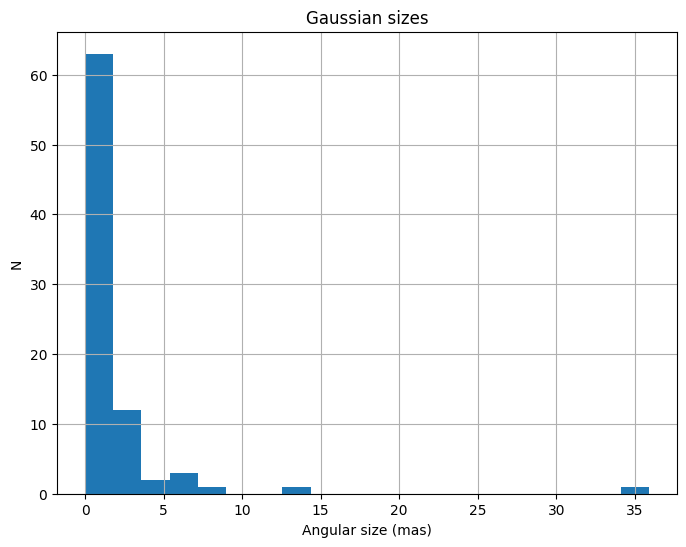

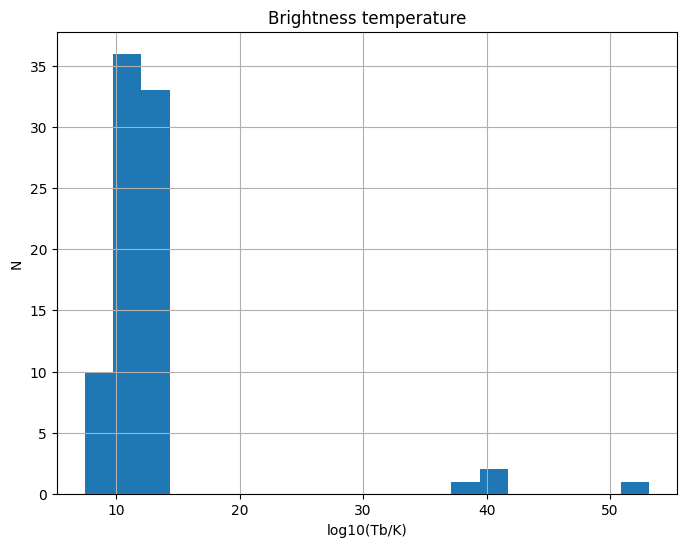

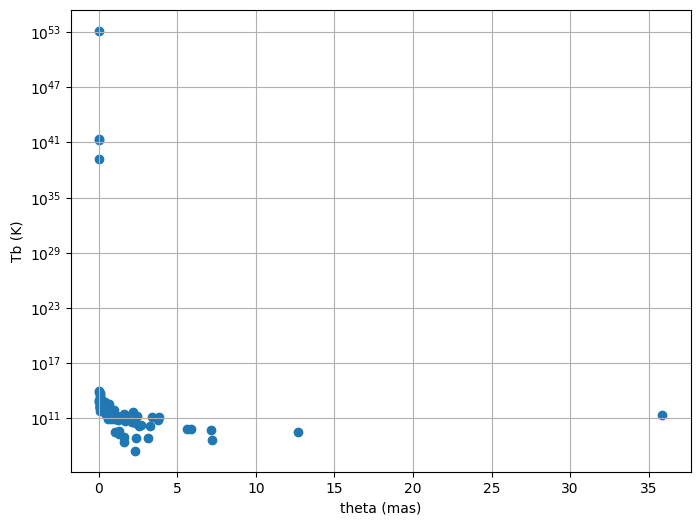


By band
      theta_mas          Tb_K
band                         
C      0.591286  3.513025e+11
K      0.050000  1.217494e+12
L      1.697421  4.129021e+11

By mode
             theta_mas          Tb_K
mode                                
GVLBI         1.258321  7.583821e+10
RADIOASTRON   0.343961  9.751685e+11

Smallest sizes


,session,date,band,theta_mas,Tb_K
45,RAKS08IM,20141204T060000,C,1.059110e-21,1.373569e+53
72,RAKS12IS,20151212T080000,C,1.603303e-16,1.801042e+41
8,RAES03IK,20121226T220000,K,8.722308e-16,1.481775e+39
11,RAES03OF,20130312T202000,L,2.095230e-15,2.161442e+41
66,RAKS12GQ,20151117T190000,C,8.470685e-03,8.755513e+13
81,RAKS12SY,20160329T010000,K,1.087444e-02,9.648455e+12
51,RAKS08JQ,20141214T080000,K,1.191183e-02,6.822589e+13
77,RAKS12LF,20160108T050000,K,1.964856e-02,7.982139e+12
39,RAKS01XF,20140327T000000,K,3.008459e-02,5.295099e+12
84,RAKS12UN,20160413T225200,K,5.000000e-02,2.194413e+12



Highest Tb


,session,date,band,theta_mas,Tb_K
45,RAKS08IM,20141204T060000,C,1.059110e-21,1.373569e+53
11,RAES03OF,20130312T202000,L,2.095230e-15,2.161442e+41
72,RAKS12IS,20151212T080000,C,1.603303e-16,1.801042e+41
8,RAES03IK,20121226T220000,K,8.722308e-16,1.481775e+39
66,RAKS12GQ,20151117T190000,C,8.470685e-03,8.755513e+13
51,RAKS08JQ,20141214T080000,K,1.191183e-02,6.822589e+13
61,RAKS08UR,20150403T220000,C,7.701276e-02,5.502597e+13
4,RAES03FW,20121119T081000,C,5.000000e-02,4.299542e+13
105,RAKS16FU,20161209T070000,C,5.000000e-02,2.866500e+13
56,RAKS08TO,20150327T001000,C,9.067811e-02,1.309173e+13


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "gaussian_fits/gaussian_fit_log.csv"

df = pd.read_csv(CSV)

print("Total rows:", len(df))

print("\nStatus:")
print(df["status"].value_counts())

# ----------------------------------------
# только успешные фиты
# ----------------------------------------

ok = df[df.status == "OK"].copy()

print("\nSuccessful fits:", len(ok))

# ----------------------------------------
# очистка
# ----------------------------------------

ok = ok.replace(
    [np.inf, -np.inf],
    np.nan
)

ok = ok.dropna(
    subset=[
        "theta_mas",
        "Tb_K"
    ]
)

print("Valid fits:", len(ok))

# ----------------------------------------
# статистика
# ----------------------------------------

print("\nTheta [mas]")

print(
    ok["theta_mas"].describe()
)

print("\nTb [K]")

print(
    ok["Tb_K"].describe()
)

# ----------------------------------------
# histogram theta
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    ok["theta_mas"],
    bins=20
)

plt.xlabel("Angular size (mas)")
plt.ylabel("N")

plt.title("Gaussian sizes")

plt.grid()

plt.show()

# ----------------------------------------
# histogram Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    np.log10(ok["Tb_K"]),
    bins=20
)

plt.xlabel("log10(Tb/K)")
plt.ylabel("N")

plt.title("Brightness temperature")

plt.grid()

plt.show()

# ----------------------------------------
# theta vs Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    ok["theta_mas"],
    ok["Tb_K"]
)

plt.yscale("log")

plt.xlabel("theta (mas)")
plt.ylabel("Tb (K)")

plt.grid()

plt.show()

# ----------------------------------------
# by band
# ----------------------------------------

print("\nBy band")

print(
    ok.groupby("band")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# by mode
# ----------------------------------------

print("\nBy mode")

print(
    ok.groupby("mode")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# compact epochs
# ----------------------------------------

print("\nSmallest sizes")

display(

    ok.sort_values(
        "theta_mas"
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "Tb_K"
        ]
    ].head(20)

)

# ----------------------------------------
# hottest epochs
# ----------------------------------------

print("\nHighest Tb")

display(

    ok.sort_values(
        "Tb_K",
        ascending=False
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "Tb_K"
        ]
    ].head(20)

)

In [6]:
# только Радиоастрон

ra = ok[
    ok["mode"] == "RADIOASTRON"
]

plt.figure(figsize=(10,6))

plt.errorbar(
    pd.to_datetime(
        ra["date"],
        format="%YYY%mm%dd"
    ),
    ra["theta_mas"],
    yerr=ra["theta_mas_err"],
    fmt="o"
)

plt.xlabel("Date")
plt.ylabel("Angular size (mas)")
plt.grid()

plt.show()

ValueError: time data "20120427T213000" doesn't match format "%YYY%mm%dd", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

<Figure size 1000x600 with 0 Axes>